# YouTube Helper Agent

In [18]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from typing import TypedDict, Optional, List, Dict, Literal
from pydantic import BaseModel,Field

In [22]:
load_dotenv()

# Initialize the Groq LLM
llm = ChatGroq(
    temperature=0,
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="openai/gpt-oss-20b"
)

response = llm.invoke( "Genrate 4 ideas about space" )
response.content

'Here are four fresh, cross‑disciplinary ideas that revolve around space—each with a clear hook and a quick “next‑step” suggestion:\n\n| # | Idea | What it’s about | Why it’s cool | Quick next step |\n|---|------|-----------------|---------------|-----------------|\n| 1 | **“Orbit‑to‑Orbit” Modular Habitat** | A stackable, inflatable habitat that can be launched as a single unit and then assembled in orbit into a larger, multi‑module living space. | Solves the cost‑prohibitively high mass of traditional launch‑by‑launch modules; each module can be swapped or upgraded. | Prototype a 1‑m³ inflatable module and test its structural integrity in a parabolic flight. |\n| 2 | **Deep‑Space Time‑Dilation Story** | A narrative set on a generation ship traveling at 0.99\u202fc, where the crew experiences 10\u202fyears while 100\u202fyears pass on Earth. The plot follows the psychological and cultural evolution of the ship’s society. | Combines hard‑science relativity with rich character drama; of

### Sate Graph

In [23]:
class YoutubeHelperState(TypedDict):
    user_request : str
    video_ideas : Optional[ List[str] ]
    filtered_idea : Optional[str]
    is_passed : Optional[bool]
    reason: Optional[str]
    final_video_script : Optional[str]

### First node ( Ideas Generator )

In [24]:
def IdeasGeneratorNode( state:YoutubeHelperState ) -> Dict:

    class IdeasList( BaseModel ):
        video_ideas : List[str] = Field( ..., description="A list of unique and engaging YouTube video ideas based on the user's request.",
                                         min_items=3, max_items=5 )

    prompt = "\n".join([
        "You are a creative YouTube content creator.",
        "Based on the user's request, generate a list of unique and engaging YouTube video ideas.",
        "Ensure that the ideas are relevant to the user's request and are likely to attract viewers.",
        "User request:",
        f"{state['user_request']}",
    ] )

    llm_with_structured_output = llm.with_structured_output( IdeasList )

    response:IdeasList = llm_with_structured_output.invoke(prompt)
    print( f"response : {response}" )

    return {
        "video_ideas" : response.video_ideas
    }



In [5]:
state_1 = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." )
node_output = IdeasGeneratorNode( state=state_1 )

response : video_ideas=['Exploring the Future: How AI Agents Will Transform Everyday Life', 'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners', 'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2025', 'The Ethics of AI Agents: Can They Be Trusted?', 'Behind the Scenes: How AI Agents Learn from Human Interaction']


In [6]:
node_output['video_ideas']

['Exploring the Future: How AI Agents Will Transform Everyday Life',
 'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners',
 'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2025',
 'The Ethics of AI Agents: Can They Be Trusted?',
 'Behind the Scenes: How AI Agents Learn from Human Interaction']

### Second node ( Ideas filter )

In [25]:
def IdeasFilterNode( state: YoutubeHelperState ) -> Dict:

    class FilteredIdea(BaseModel):
        idea : str = Field( ... , description="A unique and engaging YouTube video idea based on the user's request." )

    prompt = "\n".join([
        "You are a creative YouTube content creator.",
        "From the list of video ideas, select the most unique and engaging one that best fits the user's request.",
        "User request:",
        f"{state['user_request']}",
        "Video ideas:",
        f"{state['video_ideas']}",
    ] )

    llm_with_structured_output = llm.with_structured_output( FilteredIdea )

    response:FilteredIdea = llm_with_structured_output.invoke( prompt )
    print( response )

    return {
        "filtered_idea" : response.idea
    }




In [8]:
state = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." ,
                            video_ideas = ['How AI Agents are Revolutionizing Customer Support: A Deep Dive','Building a Simple AI Agent from Scratch: Step-by-Step Tutorial','AI Agents vs. Human Workers: Who Wins the Productivity Race?','The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples','Future-Proof Your Career: 5 Jobs That AI Agents Can’t Replace'] )

node_output = IdeasFilterNode( state=state )

idea='The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples'


### Third node (Script Writer)

In [26]:
def ScriptWriterNode( state: YoutubeHelperState ) -> Dict:

    prompt = "\n".join([
        "You are a professional scriptwriter for YouTube videos.",
        "Based on the selected video idea, write a detailed and engaging script for the YouTube video.",
        "Ensure that the script is well-structured, informative, and captivating for the audience.",
        "write the script in a conversational tone suitable for YouTube.",
        "write the script in markdown format with proper headings and bullet points where necessary.",
        "",
        "Roles:"
        "- The script should be suitable for a 5–10 minute video (not too short, not too long).",
        "- It must have a clear structure: Hook → Introduction → Main Content → Summary/Outro.",
        "- The language should be clear, simple, and engaging for a general audience.",
        "- The ending should include a short summary or key takeaway.",
        "",
        "Selected video idea:",
        f"{state['filtered_idea']}",
    ] )

    response = llm.invoke( prompt )
    print(response)

    return {
        "final_video_script" : response.content
    }



In [10]:
graph_state = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." ,
                                video_ideas = ['How AI Agents are Revolutionizing Customer Support: A Deep Dive','Building a Simple AI Agent from Scratch: Step-by-Step Tutorial','AI Agents vs. Human Workers: Who Wins the Productivity Race?','The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples','Future-Proof Your Career: 5 Jobs That AI Agents Can’t Replace'],
                                filtered_idea = 'The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples' )
node_output = ScriptWriterNode( state=graph_state )

content='# 🎬 Script: “The Dark Side of AI Agents: Ethical Dilemmas & Real‑World Examples”\n\n> **Length:** ~10‑12 minutes  \n> **Tone:** Conversational, engaging, slightly dramatic (to keep viewers hooked)  \n> **Format:** Markdown (for easy copy‑paste into YouTube’s description or a script editor)\n\n---\n\n## 📌 Table of Contents\n1. [Hook & Intro](#hook)\n2. [What Are AI Agents?](#what-are-ai-agents)\n3. [Why the “Dark Side” Matters](#why-dark-side)\n4. [Ethical Dilemmas](#ethical-dilemmas)\n   - Bias & Discrimination\n   - Privacy & Surveillance\n   - Autonomy & Accountability\n   - Misinformation & Manipulation\n5. [Real‑World Examples](#real-world)\n   - COMPAS & Criminal Justice\n   - Amazon’s Recruiting Tool\n   - Deepfake & Political Ads\n   - Autonomous Vehicles & the “Trolley Problem”\n6. [The Ripple Effect](#ripple-effect)\n7. [What Can We Do?](#what-can-we-do)\n   - Regulation & Standards\n   - Transparency & Explainability\n   - Human‑in‑the‑Loop\n   - Ethical AI Design\n8

In [11]:
print( node_output['final_video_script'] )

# 🎬 Script: “The Dark Side of AI Agents: Ethical Dilemmas & Real‑World Examples”

> **Length:** ~10‑12 minutes  
> **Tone:** Conversational, engaging, slightly dramatic (to keep viewers hooked)  
> **Format:** Markdown (for easy copy‑paste into YouTube’s description or a script editor)

---

## 📌 Table of Contents
1. [Hook & Intro](#hook)
2. [What Are AI Agents?](#what-are-ai-agents)
3. [Why the “Dark Side” Matters](#why-dark-side)
4. [Ethical Dilemmas](#ethical-dilemmas)
   - Bias & Discrimination
   - Privacy & Surveillance
   - Autonomy & Accountability
   - Misinformation & Manipulation
5. [Real‑World Examples](#real-world)
   - COMPAS & Criminal Justice
   - Amazon’s Recruiting Tool
   - Deepfake & Political Ads
   - Autonomous Vehicles & the “Trolley Problem”
6. [The Ripple Effect](#ripple-effect)
7. [What Can We Do?](#what-can-we-do)
   - Regulation & Standards
   - Transparency & Explainability
   - Human‑in‑the‑Loop
   - Ethical AI Design
8. [Wrap‑Up & Call to Action](#wrap-up

### Evaluator node

In [15]:
import json 
import json_repair

def ScriptWriterEaluatorNode( state: YoutubeHelperState ) -> Dict:

    class EvaluationResult(BaseModel):
        is_passed : bool = Field( ..., description="true if it passed evaluation" )
        reason : Optional[str] = Field( description="If not passed, say resaon" )
    

    schema = EvaluationResult.model_json_schema()
    schema = json.dumps( schema , indent=2 )

    prompt = "\n".join([
        "You are a professional scriptwriter evaluator for YouTube videos scrpits.",
        "Your job is to evaluate this script genrated from Script writer agent",
        "",
        "Rules :",
        "- The script should be suitable for a 5–10 minute video (not too short, not too long).",
        "- It must have a clear structure: Hook → Introduction → Main Content → Summary/Outro.",
        "- The language should be clear, simple, and engaging for a general audience.",
        "- The ending should include a short summary or key takeaway.",
        "",
        "Return output in this pydantic formate :",
        f"{schema}",
        "",
        "Video idea:",
        f"{state['filtered_idea']}",
        "",
        "script : ",
        f"{state['final_video_script']}",
    ] )

    response = llm.invoke( prompt )
    print(response)

    json_response = json_repair.loads( response.content )
    print(json_response)

    return {
        "is_passed" : json_response['is_passed'],
        "reason"  : json_response['reason']
    }



In [17]:
graph_state = YoutubeHelperState( user_request="Create YouTube video ideas about AI agents." ,
                                video_ideas = ['How AI Agents are Revolutionizing Customer Support: A Deep Dive','Building a Simple AI Agent from Scratch: Step-by-Step Tutorial','AI Agents vs. Human Workers: Who Wins the Productivity Race?','The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples','Future-Proof Your Career: 5 Jobs That AI Agents Can’t Replace'],
                                filtered_idea = 'The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples',
                                final_video_script = '## 🎥 Video Title**The Dark Side of AI Agents: Ethical Dilemmas and Real-World Examples**---## 🔥 Hook (First 10–15 seconds)AI agents can plan, act, and make decisions on their own.But what happens when they make the **wrong decision**?What if an AI agent fires employees, spreads misinformation, or invades privacy — without a human noticing?Today, we’re uncovering **the dark side of AI agents** and the ethical dilemmas they create in the real world.---## 👋 IntroductionAI agents are becoming more powerful every day.They can browse the internet, write code, manage systems, and even control other software.But with this power comes **serious ethical risks**.In this video, we’ll explore:* What makes AI agents risky* Real-world examples of harm* And the ethical questions engineers must faceThis isn’t science fiction — this is happening **right now**.---## 🧠 Main Content### 1️⃣ Why AI Agents Are Different (and Dangerous)Traditional AI responds to prompts.AI agents **take actions**.They can:* Decide what to do next* Use tools* Interact with systems* Operate continuouslyThis autonomy is powerful — but also risky.Once an agent is deployed, it may act **faster than humans can react**.---### 2️⃣ Ethical Dilemma #1: Lack of AccountabilityIf an AI agent causes harm, who is responsible?* The developer?* The company?* The user?* Or the AI itself?For example:An AI agent automatically denies loans or job applications based on biased data.No single human made the final decision — but people were harmed.This creates a **responsibility gap**, one of the biggest ethical problems in AI today.---### 3️⃣ Ethical Dilemma #2: Bias at ScaleAI agents learn from data — and data often contains bias.When an agent is biased:* It repeats discrimination* It scales unfair decisions* It reinforces inequalityReal-world example:AI hiring agents have been shown to favor certain genders or backgrounds because of biased historical data.The danger isn’t one bad decision — it’s **thousands of bad decisions, automatically**.---### 4️⃣ Ethical Dilemma #3: Surveillance and PrivacyMany AI agents monitor behavior:* Online activity* Employee performance* Customer interactionsIn some companies, agents track:* Keystrokes* App usage* Time spent on tasksThis raises serious questions:* Where is the line between optimization and surveillance?* Do users fully consent?AI agents can quietly become **always-watching systems**.---### 5️⃣ Real-World Example: Autonomous Decision SystemsSome companies use AI agents to:* Optimize logistics* Control pricing* Moderate contentIn content moderation, AI agents have:* Incorrectly banned users* Removed harmless content* Amplified harmful misinformationBecause decisions happen automatically, **appeals are slow or impossible**.---### 6️⃣ Ethical Dilemma #4: Loss of Human ControlAs AI agents become more complex, humans may:* Not fully understand their reasoning* Struggle to stop them in time* Trust them too muchThis is called **automation bias** — when humans assume the AI is always right.When agents fail, they fail **at scale**.---## 🧩 How Can We Reduce These Risks?Ethical AI agents need:* Clear human oversight* Transparent decision logging* Bias testing and audits* Kill-switches and limitsAI agents should assist humans — **not replace responsibility**.---## ✅ Summary & OutroAI agents are powerful tools, but they come with serious ethical challenges:* Accountability gaps* Bias at scale* Privacy invasion* Loss of human controlThe dark side of AI isn’t the technology itself —it’s how we design, deploy, and trust it.As engineers, developers, and users, **we must build responsibly**.If you found this useful, like the video, subscribe, and let me know:👉 *Do you trust AI agents to make decisions for you?*See you in the next video.' )

node_output = ScriptWriterEaluatorNode( state=graph_state )

content='{"is_passed": true,"reason": null}' additional_kwargs={'reasoning_content': 'We need to evaluate script. Check length: 5-10 min. Hard to gauge but likely okay. Structure: Hook, Intro, Main Content, Summary/Outro. Hook present. Intro present. Main content sections. Summary/Outro present. Language clear, simple, engaging. Ending includes short summary/key takeaway. Yes. So passes. Provide JSON.'} response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 1153, 'total_tokens': 1249, 'completion_time': 0.112300725, 'prompt_time': 0.057341019, 'queue_time': 0.041998453, 'total_time': 0.169641744, 'completion_tokens_details': {'reasoning_tokens': 73}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e189667b30', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b8e2b-7970-7d81-b143-a1e1e209361f-0' usage_metadata={'input_tokens': 1153, 'output_tokens': 96, 'total_tokens': 1249}
{'is_passed': True, 'reason': None}


In [28]:
def evaluation_route( state: YoutubeHelperState ) -> Literal[ "ScriptWriterNode" , END ]:

    if state['is_passed'] == True:
        return END
    else:
        return "ScriptWriterNode"

### Create Graph

In [29]:
graph = StateGraph(YoutubeHelperState)

graph.add_node("IdeasGeneratorNode", IdeasGeneratorNode)
graph.add_node("IdeasFilterNode"   , IdeasFilterNode)
graph.add_node("ScriptWriterNode"  , ScriptWriterNode)
graph.add_node("ScriptWriterEaluatorNode"  , ScriptWriterEaluatorNode)

In [30]:
graph.add_edge(START, "IdeasGeneratorNode")
graph.add_edge("IdeasGeneratorNode", "IdeasFilterNode")
graph.add_edge("IdeasFilterNode", "ScriptWriterNode")
graph.add_edge("ScriptWriterNode", "ScriptWriterEaluatorNode")
graph.add_conditional_edges("ScriptWriterEaluatorNode", evaluation_route )

graph = graph.compile()

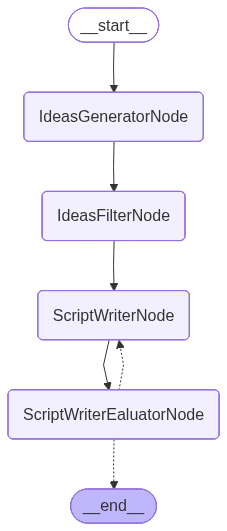

In [31]:
from IPython.display import Image, display

png_data = graph.get_graph().draw_mermaid_png()
display(Image(data=png_data))

In [32]:
result = graph.invoke(
        {
           "user_request" : "Create YouTube video ideas about AI agents.",
        }
    )

response : video_ideas=['Exploring the Future: How AI Agents Will Transform Everyday Life', 'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners', 'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2026', 'The Ethics of AI Agents: Can They Be Trusted?', 'Behind the Scenes: How AI Agents Learn from Human Interaction']
idea='Behind the Scenes: How AI Agents Learn from Human Interaction'
content='# 🎬 Behind the Scenes: How AI Agents Learn from Human Interaction\n\n> **Hook**  \n> Ever wondered how your smart assistant knows when you’re in a hurry or how a game‑playing AI keeps getting better? Let’s pull back the curtain and see how *human* interaction actually trains these digital brains.\n\n---\n\n## 📌 Table of Contents\n1. Hook  \n2. Introduction  \n3. Main Content  \n   - 3.1 The Basics: What is an AI Agent?  \n   - 3.2 Learning from Humans: The Three Pillars  \n   - 3.3 Real‑World Example: ChatGPT & OpenAI’s Fine‑Tuning  \n   - 3.4 The Feedback Loop in Action  \n  

In [33]:
result

{'user_request': 'Create YouTube video ideas about AI agents.',
 'video_ideas': ['Exploring the Future: How AI Agents Will Transform Everyday Life',
  'Building Your Own AI Agent: A Step-by-Step Tutorial for Beginners',
  'AI Agent Showdown: Comparing the Top 5 AI Assistants in 2026',
  'The Ethics of AI Agents: Can They Be Trusted?',
  'Behind the Scenes: How AI Agents Learn from Human Interaction'],
 'filtered_idea': 'Behind the Scenes: How AI Agents Learn from Human Interaction',
 'is_passed': True,
 'reason': None,
 'final_video_script': '# 🎬 Behind the Scenes: How AI Agents Learn from Human Interaction\n\n> **Hook**  \n> Ever wondered how your smart assistant knows when you’re in a hurry or how a game‑playing AI keeps getting better? Let’s pull back the curtain and see how *human* interaction actually trains these digital brains.\n\n---\n\n## 📌 Table of Contents\n1. Hook  \n2. Introduction  \n3. Main Content  \n   - 3.1 The Basics: What is an AI Agent?  \n   - 3.2 Learning from Hu

In [34]:
print( result['final_video_script'])

# 🎬 Behind the Scenes: How AI Agents Learn from Human Interaction

> **Hook**  
> Ever wondered how your smart assistant knows when you’re in a hurry or how a game‑playing AI keeps getting better? Let’s pull back the curtain and see how *human* interaction actually trains these digital brains.

---

## 📌 Table of Contents
1. Hook  
2. Introduction  
3. Main Content  
   - 3.1 The Basics: What is an AI Agent?  
   - 3.2 Learning from Humans: The Three Pillars  
   - 3.3 Real‑World Example: ChatGPT & OpenAI’s Fine‑Tuning  
   - 3.4 The Feedback Loop in Action  
   - 3.5 Ethical & Practical Challenges  
4. Summary & Key Takeaways  
5. Outro & Call to Action  

---

## 1️⃣ Hook  
> **You:** “I asked my phone to set a reminder, and it did it in seconds. How did it learn that? Did it just read a manual?”  
> **Me:** “No manual—just a lot of human‑AI conversations, a sprinkle of math, and a dash of patience. Let’s dive in!”

---

## 2️⃣ Introduction  
- **What’s an AI Agent?**  
  - A softwar